In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp
import xplt


import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [6]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import *
from optimisers import *


# Importing the sequence


In [7]:
from elements import install_septa
line = xt.Line.from_json("../database/lhc_q22.json")
#line = xt.Line.from_json("sps_for_sx.json")



# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
line.insert_element("TECA.exit", xt.Marker(), at_s = 4020.8939 + TECS.length)

#line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )

line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)

teca_entry_s = line.get_table()['s', 'TECA.entry']

#line.cycle("TECA.entry", inplace=True)


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4603 [00:00<?, ?it/s]

In [8]:
# Get the positions of the TECA and COLLIMATORS markers
teca_position = line.get_table()['s', 'TECA.entry']
tpst_position = line.get_table()['s', 'tpst.21760_entry']
tcsm_position = line.get_table()['s', 'tcsm.51932.']

In [9]:
print_optics_features(line)

22.130000000065145
22.180000000051958
D term / B term = 3.31
sigma_x max = 10.468444860741442 mm
sigma_y max = 1.1036200168605912 mm
D term / B term = 3.31
sigma_x max = 0.010468444860741442 m
sigma_y max = 0.001103620016860591 m
Phase advance Teca - Tpst: -7.39
Phase advance Teca - Tcsm: 3.83
Phase advance Tpst - Tcsm: 11.22


## Matching the tunes

In [10]:
#tune = 22.91
tune = 24.39

In [11]:

optTune = match_tunes(line, tune, tune - 0.02)
optChromaticity = match_chromaticity(line, tune, tune - 0.02)

optTune.step(10)
optTune.target_status()
optTune.vary_status()

# CHanging the chromaticity afterwards
optChromaticity.step(10)

optChromaticity.target_status()
optChromaticity.vary_status() 

line.discard_tracker()




                                             
Optimize - start penalty: 31.47         
Matching: model call n. 19               
Optimize - end penalty:  1.05384e-09
Target status:                           
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx     True   2.96225e-11         24.39         24.39 'qx', val=24.39, tol=1e-05, weight=10
1  ON    qy     True   1.01135e-10         24.37         24.37 'qy', val=24.37, tol=1e-05, weight=10
Vary status:                 
id state tag met name         lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqf          None            0.0136431 None            0.0125751         1e-07             1
1  ON        OK  kqd          None           -0.0136257 None           -0.0125777         1e-07             1
2  ON        OK  qph_setvalue None          4.63538e-14 None                    0        0.0001             1
3  ON        OK  qp

In [12]:
tw = line.twiss(method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')



# Find apertures tha block the particles and open them

In [13]:
blocking_elements = open_blocking_apertures(line, TECA, deltaP_P)

The line already has an associated tracker
Non-channeled particle lost at element qe.11402_aper (index 250) on turn 0
Adjusting qe.11402_aper: expanding LimitEllipse aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21774_aper (index 1117) on turn 0
Adjusting ap.up.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21774_aper (index 1122) on turn 0
Adjusting ap.do.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21779_aper (index 1125) on turn 0
Adjusting ap.up.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21779_aper (index 1130) on turn 0
Adjusting ap.do.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lo

In [14]:
import elements 
import importlib
importlib.reload(elements)

remove_ZS_apertures(line)
remove_inner_sideLimits_closeTECA(line)

Opening aperture for element: ap.up.zs21633_aper
Element ap.up.zs21633 does not have adjustable apertures.
Element drift_zs.21633..1..0 does not have adjustable apertures.
Element zs21633.entry.p1mm does not have adjustable apertures.
Element drift_zs.21633..1..1 does not have adjustable apertures.
Element zs.21633 does not have adjustable apertures.
Element drift_zs.21633..2 does not have adjustable apertures.
Opening aperture for element: ap.do.zs21633_aper
Element ap.do.zs21633 does not have adjustable apertures.
Element drift_458 does not have adjustable apertures.
Element drift_zs.21639..1 does not have adjustable apertures.
Element zs.21639 does not have adjustable apertures.
Element drift_zs.21639..2 does not have adjustable apertures.
Element drift_459 does not have adjustable apertures.
Opening aperture for element: ap.up.zs21655_aper
Element ap.up.zs21655 does not have adjustable apertures.
Element drift_zs.21655..1 does not have adjustable apertures.
Element zs.21655 does no

In [15]:
save_df_Limit_elements_features(line)

      Position         Element Name    max_x    min_x
0     445.9241        qe.11402_aper  0.15200 -0.15200
1     543.9610        qd.11710_aper  0.04150 -0.04150
2     548.3640      mdhw.11732_aper  0.07600 -0.07600
3     552.1253      mdhw.11737_aper  0.07600 -0.07600
4     553.1843      mdhw.11738_aper  0.07600 -0.07600
..         ...                  ...      ...      ...
102  6349.1332  ap.do.mse61852_aper  0.06582 -0.06582
103  6349.9872  ap.up.mse61857_aper  0.06850 -0.06850
104  6352.3672  ap.do.mse61857_aper  0.07635 -0.07635
105  6353.2212  ap.up.mse61872_aper  0.08024 -0.08024
106  6355.6012  ap.do.mse61872_aper  0.09100 -0.09100

[107 rows x 4 columns]


,Position,Element Name,max_x,min_x
0,445.9241,qe.11402_aper,0.15200,-0.15200
1,543.9610,qd.11710_aper,0.04150,-0.04150
2,548.3640,mdhw.11732_aper,0.07600,-0.07600
3,552.1253,mdhw.11737_aper,0.07600,-0.07600
4,553.1843,mdhw.11738_aper,0.07600,-0.07600
...,...,...,...,...
102,6349.1332,ap.do.mse61852_aper,0.06582,-0.06582
103,6349.9872,ap.up.mse61857_aper,0.06850,-0.06850
104,6352.3672,ap.do.mse61857_aper,0.07635,-0.07635
105,6353.2212,ap.up.mse61872_aper,0.08024,-0.08024


In [16]:
# Save the line with the current optics into a JSON file
line.to_json("../database/lhc_q24.json")

# Adjusting the knobs

In [17]:
import optimisers as op
import importlib
importlib.reload(op)

# Define the target x and px values
#x_target = line['tpst.21760_entry.sep'].interaction_process.blade_position 
#px_target = recordNONCH.px[np.where(recordNONCH.s == tpst_position)[0][0]]
px_target = 1e-4
#x_target = 0.0394 * 1.90  # This is the position of the TPST blade times a factor, THIS VALUE IS GOOD FOR THE ORIGINAL POSITION OF THE SEPTUM
x_target = 0.0394 * 1.8



# Adjust the horizontal bump for the extraction
adjustBumpLSS2 = op.horizontal_bumpLSS2(line, x_target * 0.5, px_target)

adjustBumpLSS2.log()

adjustBumpLSS2.step(10)
adjustBumpLSS2.target_status()
adjustBumpLSS2.vary_status()
knobs_after_matchLSS2 = adjustBumpLSS2.get_knob_values()
knobs_before_matchLSS2 = adjustBumpLSS2.get_knob_values(iteration=0)


# Adjust the horizontal bump for the TECA
adjustBumpLSS4 = op.horizontal_bumpLSS4(line)

adjustBumpLSS4.log()

adjustBumpLSS4.step(10)
adjustBumpLSS4.target_status()
adjustBumpLSS4.vary_status()
knobs_after_matchLSS4 = adjustBumpLSS4.get_knob_values()
knobs_before_matchLSS4 = adjustBumpLSS4.get_knob_values(iteration=0)


                                             
Optimize - start penalty: 0.3547        
Matching: model call n. 22               
Optimize - end penalty:  8.48566e-15
                                             
Optimize - start penalty: 8.486e-15      
Matching: model call n. 25               
Optimize - end penalty:  8.48566e-15
Target status:                           
id state tag                 tol_met       residue   current_val    target_val description                                 
0  ON    START_x                True             0             0             0 ('x', 'mpsh.21202'), val=0, tol=1e-09, w ...
1  ON    START_px               True             0             0             0 ('px', 'mpsh.21202'), val=0, tol=1e-09,  ...
2  ON    tpst.21760_entry_x     True   1.45717e-16       0.03546       0.03546 ('x', 'tpst.21760_entry'), val=0.03546,  ...
3  ON    tpst.21760_entry_px    True   7.68428e-18        0.0001        0.0001 ('px', 'tpst.21760_entry'), val=0.0001,  ...
4  ON

In [18]:
print("Extraction Bump values after the matching:")
print(knobs_after_matchLSS2)
print("Extraction Bump values before the matching:")
print(knobs_before_matchLSS2)

Extraction Bump values after the matching:
{'kmpsh21202': np.float64(-0.00016760629593428833), 'kmplh21431': np.float64(0.0007566923650145751), 'kmpnh21732': np.float64(-0.00015330680900608253), 'kmplh21995': np.float64(0.0006565212149608163), 'kmplh22195': np.float64(-0.0006666199792922313)}
Extraction Bump values before the matching:
{'kmpsh21202': 0.0, 'kmplh21431': 0.0, 'kmpnh21732': 0.0, 'kmplh21995': 0.0, 'kmplh22195': 0.0}


In [19]:
print("TECA Bump values after the matching:")
print(knobs_after_matchLSS4)
print("TECA Bump values before the matching:")
print(knobs_before_matchLSS4)

TECA Bump values after the matching:
{'kmpsh41402': np.float64(0.0003000645667372908), 'kmplh41658': np.float64(-0.0008485271817761151), 'kmplh41994': np.float64(-0.00029846076418409313), 'kmpsh42198': np.float64(-0.0006307549048798543)}
TECA Bump values before the matching:
{'kmpsh41402': 0.0, 'kmplh41658': 0.0, 'kmplh41994': 0.0, 'kmpsh42198': 0.0}


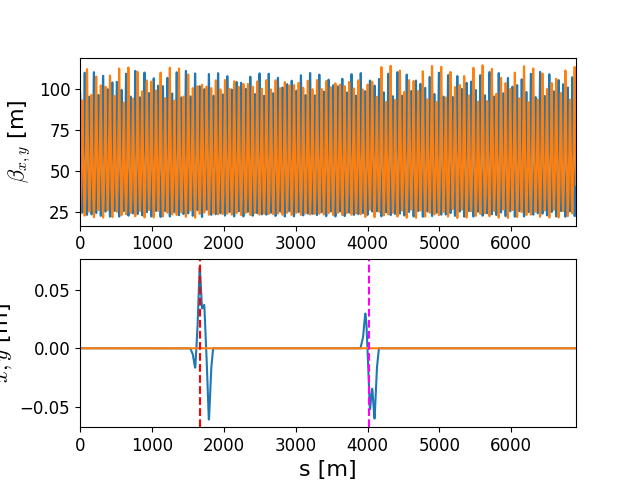

VarsTable: 367 rows, 3 cols
name             value expr
t_turn_s             0 None
version          50902 None
pi             3.14159 None
twopi          6.28319 None
degrad         57.2958 None
raddeg       0.0174533 None
e              2.71828 None
amu0       1.25664e-06 None
emass      0.000510999 None
mumass        0.105658 None
...
kmdv62907             0 None
kloe63002             0 None
kmdh63007             0 None
kmdv63107             0 None
kmdh63207             0 None
kmdv63307             0 None
kmdh63407             0 None
kmdv63507             0 None
kloe63602             0 None
kmdh63607             0 None

In [20]:
tw = line.twiss(continue_on_closed_orbit_error=True, method = '4d')

plt.figure()
ax1 = plt.subplot(2, 1, 1)
plt.plot(tw.s, tw.betx)
plt.plot(tw.s, tw.bety)
plt.ylabel(r"$\beta_{x,y}$ [m]")
plt.xlim(0,6900)
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
plt.plot(tw.s, tw.x)
plt.plot(tw.s, tw.y)
plt.axvline(tw["s", "zs.21633"], color="red", ls="--")
plt.axvline(tw["s", "TECA.entry"], color="magenta", ls="--")
plt.ylabel(r"$x,y$ [m]")
plt.xlabel("s [m]")
plt.show()
plt.xlim(0,6900)


n_part = 200

x_norm, px_norm = xp.generate_2D_gaussian(num_particles=n_part)
y_norm, py_norm = xp.generate_2D_gaussian(num_particles=n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * DPP

particles: xt.Particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

line_df = line.to_pandas()

line.vars.get_table()


# Installing the septa to extract the particles

In [21]:
line.discard_tracker()
septa_names_with_apertures = install_septa(line, install_zs=False)

In [22]:
print(septa_names_with_apertures)

['tpst.21760_entry.sep', 'mst.21774.sep', 'mst.21779.sep', 'mst.21794.sep', 'mse.21832.sep', 'mse.21837.sep', 'mse.21852.sep', 'mse.21857.sep', 'mse.21872.sep']


# Plotting optical functions at injection TT10

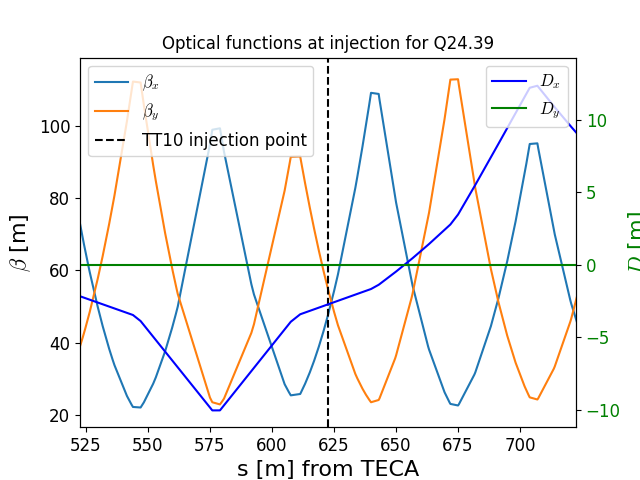

In [23]:
# Get the position of the element mkp.11955
mkp_position = line.get_table()['s', 'mkp.11955']

# Define the range around the element
x_range = (mkp_position - 100, mkp_position + 100)

# Plot the Twiss parameters in the specified range
fig, ax = plt.subplots()
ax.plot(tw['s'], tw['betx'], label=r'$\beta_x$')
ax.plot(tw['s'], tw['bety'], label=r'$\beta_y$')
ax2 = ax.twinx()
ax2.plot(tw['s'], tw['dx'], 'b-', label=r'$D_x$')
ax2.plot(tw['s'], tw['dy'], 'g-', label=r'$D_y$')
ax2.set_ylabel(r'$D$ [m]', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.legend(loc='upper right')
ax.axvline(mkp_position, color='k', linestyle='--', label='TT10 injection point')
ax.set_xlim(x_range)
ax.set_xlabel('s [m] from TECA')
ax.set_ylabel(r'$\beta$ [m]')
ax.set_title("Optical functions at injection for Q24.39")
ax.legend(loc='upper left')
plt.show()
ax.grid(True)


# Save positions and re-track particles and plots

In [24]:
df_elements = save_df_Limit_elements_features(line)

      Position         Element Name    max_x    min_x
0     445.9241        qe.11402_aper  0.15200 -0.15200
1     543.9610        qd.11710_aper  0.04150 -0.04150
2     548.3640      mdhw.11732_aper  0.07600 -0.07600
3     552.1253      mdhw.11737_aper  0.07600 -0.07600
4     553.1843      mdhw.11738_aper  0.07600 -0.07600
..         ...                  ...      ...      ...
102  6349.1332  ap.do.mse61852_aper  0.06582 -0.06582
103  6349.9872  ap.up.mse61857_aper  0.06850 -0.06850
104  6352.3672  ap.do.mse61857_aper  0.07635 -0.07635
105  6353.2212  ap.up.mse61872_aper  0.08024 -0.08024
106  6355.6012  ap.do.mse61872_aper  0.09100 -0.09100

[107 rows x 4 columns]


# Tracking a realistic beam

In [25]:
deltaP_P

0.0015

In [26]:
n_part = 100



x_norm   = np.random.normal(loc = 0, scale = 1, size=n_part)
px_norm =  np.random.normal(loc = 0, scale = 1, size=n_part)  # in between being channeled and not
#x_norm  = TECA.jaw * np.ones(n_part)
#px_norm = TECA.tilt * np.ones(n_part)
y_norm, py_norm = np.zeros(n_part), np.zeros(n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * deltaP_P

line.build_tracker()

particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles_init = particles.copy()
#tw_lss2 = tw.rows['TECA.entry':'_end_point']

tw_lss2 = tw.rows[:]


The line has collective elements.
In the twiss computation collective elements are replaced by drifts


In [27]:
deltaP_P

0.0015

In [28]:
dpp

array([3.88636913e-04, 1.43837961e-03, 1.17470629e-03, 4.07922040e-05,
       1.12250512e-03, 2.69936726e-04, 8.97978611e-05, 6.28358217e-04,
       6.05965026e-04, 3.14719725e-04, 6.82231897e-04, 9.38410315e-04,
       2.76758106e-04, 6.49564859e-04, 3.68046421e-04, 1.40711644e-03,
       1.35409542e-03, 1.08684988e-04, 2.11952540e-04, 1.27504733e-03,
       1.49841269e-03, 4.32624148e-04, 1.25943200e-03, 1.49116780e-03,
       1.16409651e-03, 3.15747303e-04, 4.06007191e-04, 8.45898230e-04,
       7.25731611e-04, 1.41954107e-03, 7.21504470e-04, 6.98780646e-04,
       1.64868820e-04, 1.27516938e-03, 4.99762470e-04, 2.57782141e-04,
       7.06713999e-05, 3.21096128e-04, 8.33059773e-04, 3.63895761e-04,
       5.01548733e-04, 1.35486472e-04, 1.04097502e-03, 1.04097097e-03,
       6.22663491e-04, 1.15751382e-03, 8.96990439e-04, 1.10568698e-03,
       1.36721045e-03, 1.53312721e-05, 6.19103076e-05, 7.01462717e-04,
       6.45038004e-07, 9.82359488e-04, 8.81084911e-04, 7.23532548e-04,
      

In [29]:
# monitor particles at all unique positions between mba.21390_exit and qda.21910_exit
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
#tw_lss2_df = tw_lss2_df.loc['qd.20910':'qda.21910'] 
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

line.discard_tracker()

def set_monitor(row):
    monitor = xt.LastTurnsMonitor(n_last_turns=100, num_particles=particles._capacity, every_n_turns=1)
    line.insert_element(name=row.name+'_monitor', element=monitor, index=row.name)
    return monitor
tw_lss2_df['monitors'] = tw_lss2_df.apply(set_monitor, axis=1) 
tw_lss2_df['i_monitor'] = np.arange(len(tw_lss2_df))    

# Inserting the crystals 

In [30]:
line.discard_tracker()
line.insert_element("extraction.crystal.TECS", TECS, at_s=line.get_table()['s', 'tecs.21602'] )
line.insert_element("extraction.crystal.TECA", TECA, at_s = line.get_table()['s', 'TECA.entry'] )

Slicing line:   0%|          | 0/8697 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/8698 [00:00<?, ?it/s]

<Line  at 4635945360>

# Inserting the TCSM to block the channeled particles

In [31]:
aperture = xt.LimitRect(
    min_x=-1,  # Lower x limit in meters
    max_x=0.005,   # Upper x limit in meters
    min_y=-1,  # Lower y limit in meters
    max_y=1    # Upper y limit in meters
)

# line.insert_element("TCSM aperture", aperture, at_s = line.get_table()['s', 'tcsm.51932.'] )  # remove the comment if you want to stop the channeled particles

# Tracking the particles

In [32]:
num_turns = 100

line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu())

particles = particles_init.copy()
line.track(
    particles,
    num_turns=num_turns,
    # turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
if np.any(particles.state < 1):
    lost_particles = np.where(particles.state < 1)[0]
    print(f"Particles lost during tracking: {len(lost_particles)}")
else:
    print("No particles lost during tracking")
record = line.time_last_track

Particles lost during tracking: 28


In [33]:
tw_lss2.qx

np.float64(24.369969851358764)

In [34]:
for element_name in septa_names_with_apertures:
    x = line[element_name].interaction_process.blade_position
    thickness = line[element_name].interaction_process.thickness
    s = line.get_table()['s', element_name]
    print(f"The element {element_name} at s = {s} m has the blade position at x = {x} m")

The element tpst.21760_entry.sep at s = 1712.220300000013 m has the blade position at x = 0.0394 m
The element mst.21774.sep at s = 1716.3533000000127 m has the blade position at x = 0.04079 m
The element mst.21779.sep at s = 1719.5873000000126 m has the blade position at x = 0.0424 m
The element mst.21794.sep at s = 1722.8213000000128 m has the blade position at x = 0.0424 m
The element mse.21832.sep at s = 1733.8060000000125 m has the blade position at x = 0.0527 m
The element mse.21837.sep at s = 1737.0400000000125 m has the blade position at x = 0.05184 m
The element mse.21852.sep at s = 1740.2740000000124 m has the blade position at x = 0.05184 m
The element mse.21857.sep at s = 1743.5080000000125 m has the blade position at x = 0.05184 m
The element mse.21872.sep at s = 1746.7420000000125 m has the blade position at x = 0.05184 m


# Plotting phase space at TECA

Text(0, 0.5, "$x'$ (mrad)")

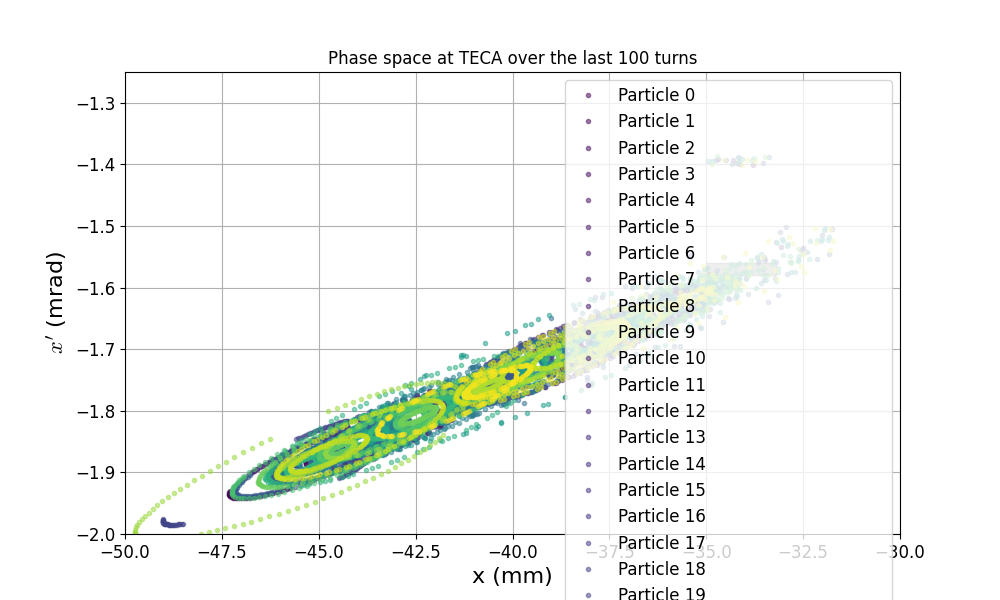

In [35]:
row_TECA_entry = tw_lss2_df.loc['TECA.entry']
row_TECA_exit = tw_lss2_df.loc['TECA.exit']


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

#ax.plot(row_TECA_entry['monitors'].x[:, :] * 1e3, row_TECA_entry['monitors'].px[:, :] * 1e3, 'k.', alpha=0.5)  ## PLOTS ONLY THE PARTICLES AT THE LAST TURN
#ax.plot(row_TECA_exit['monitors'].x[:, :] * 1e3, row_TECA_exit['monitors'].px[:, :] * 1e3, 'b.', alpha=0.5)    ## PLOTS ONLY THE PARTICLES AT THE LAST TURN

#ax.plot(row_TECA_entry['monitors'].x[:, :] * 1e3, row_TECA_entry['monitors'].px[:, :] * 1e3, 'k.', alpha= 0.5)  ## PLOTS  THE PARTICLES AT THE LAST 5 TURN
#ax.plot(row_TECA_exit['monitors'].x[:, :] * 1e3, row_TECA_exit['monitors'].px[:, :] * 1e3, 'b.', alpha= 0.5)    ## PLOTS  THE PARTICLES AT THE LAST 5 TURN


for i in range(row_TECA_exit['monitors'].x.shape[0]):
    ax.plot(
        row_TECA_exit['monitors'].x[i, :] * 1e3,
        row_TECA_exit['monitors'].px[i, :] * 1e3,
        '.', alpha=0.5, color=plt.cm.viridis(i / row_TECA_exit['monitors'].x.shape[0]),
        label=f'Particle {i}'
    )

ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')




#ax.plot([], [], 'k.', label='Particles at TECA entry')
#ax.plot([], [], 'b.', label='Particles after TECA')

ax.set_title("Phase space at TECA over the last 100 turns")
ax.legend()
ax.grid(True)

ax.set_xlim(-50, -30)
ax.set_ylim(-2, -1.25)

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

In [36]:
print(row_TECA_entry['monitors'].x.shape)

(100, 100)


# Plotting phase space at TPST


Text(0, 0.5, "$x'$ (mrad)")

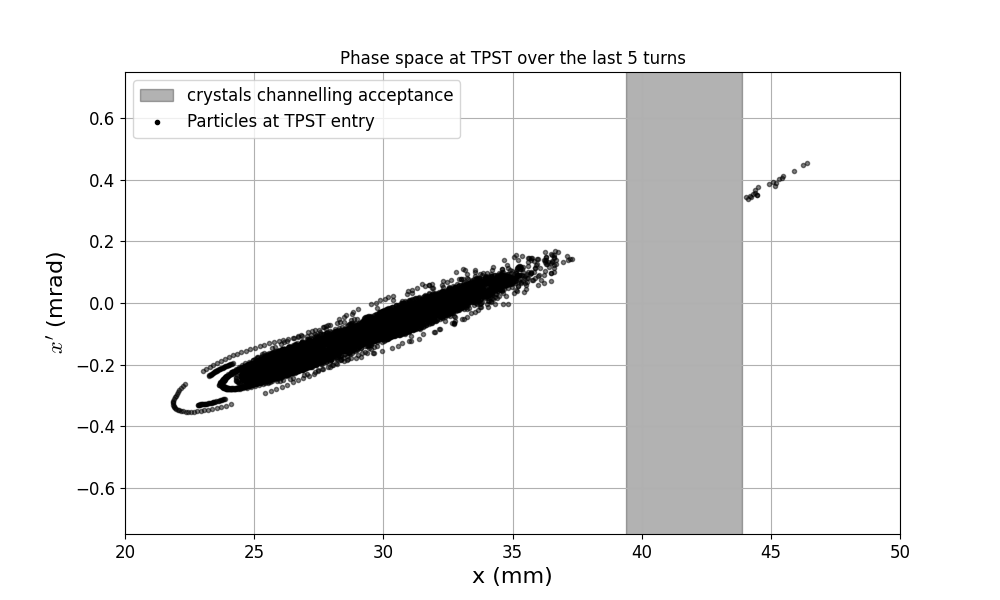

In [37]:
row_TPST_entry = tw_lss2_df.loc['tpst.21760_entry']


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(row_TPST_entry['monitors'].x[:, :] * 1e3, row_TPST_entry['monitors'].px[:, :] * 1e3, 'k.', alpha=0.5)

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
element_name = 'tpst.21760_entry.sep'
x = line[element_name].interaction_process.blade_position
thickness = line[element_name].interaction_process.thickness
ax.fill_between([x*1e3, x*1e3 + thickness*1e3],-1, 1, color='k', alpha=0.3, label='crystals channelling acceptance')



ax.plot([], [], 'k.', label='Particles at TPST entry')

ax.set_title("Phase space at TPST over the last 5 turns")

ax.legend()
ax.grid(True)

ax.set_xlim(20, 50)
ax.set_ylim(-0.75, 0.75)

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

In [38]:
mux_teca = tw_lss2_df.loc['TECA.entry', 'mux']
muy_teca = tw_lss2_df.loc['TECA.entry', 'muy']

mux_tpst = tw_lss2_df.loc['tpst.21760_entry', 'mux']
muy_tpst = tw_lss2_df.loc['tpst.21760_entry', 'muy']

phase_advance_x = mux_tpst - mux_teca
phase_advance_y = muy_tpst - muy_teca

print(f"Phase advance in x between TECA and TPST: {phase_advance_x:.4f}")
print(f"Phase advance in y between TECA and TPST: {phase_advance_y:.4f}")

Phase advance in x between TECA and TPST: -8.1365
Phase advance in y between TECA and TPST: -8.1515


# Computing the crystal acceptante at the TCSM location

In [39]:
# Extract the transfer matrix from TECA to TPST
transfer_matrix = tw.get_R_matrix(start='TECA.entry', end='tcsm.51932.')

# Define the four corners of the acceptance rectangle at TECA
corners_teca = np.array([
    [TECA.jaw, TECA.tilt - 10e-6],  # Bottom-left
    [TECA.jaw + TECA.width, TECA.tilt - 10e-6],  # Bottom-right
    [TECA.jaw, TECA.tilt + 10e-6],  # Top-left
    [TECA.jaw + TECA.width, TECA.tilt + 10e-6]  # Top-right
])


# Phase space at the TCSM

Text(0, 0.5, "$x'$ (mrad)")

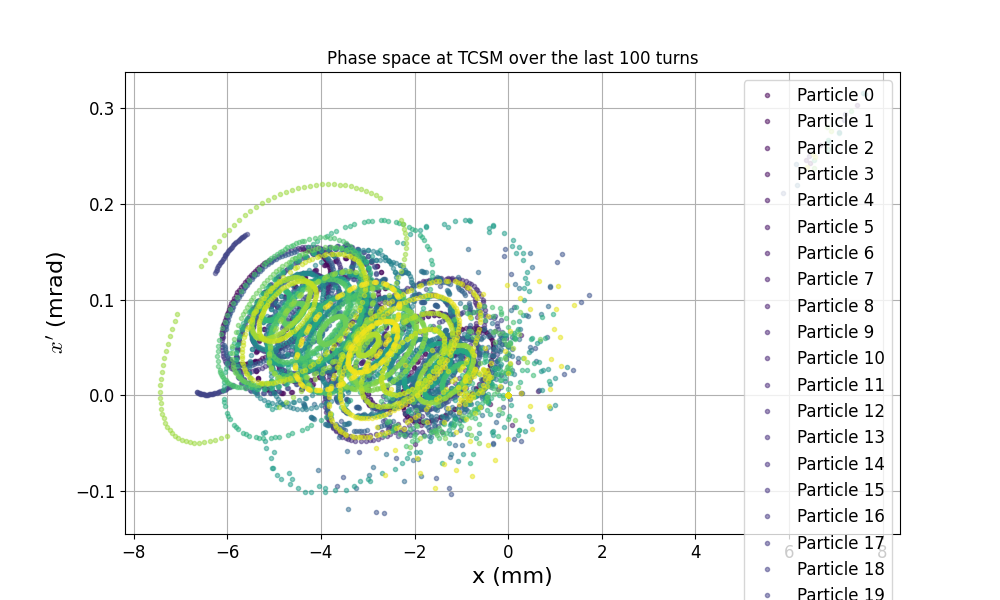

In [40]:
row_TCSM_entry = tw_lss2_df.loc['tcsm.51932.']


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

#ax.plot(row_TCSM_entry['monitors'].x[:, :] * 1e3, row_TCSM_entry['monitors'].px[:, :] * 1e3, 'k.', alpha=0.5)
#ax.fill_between([x*1e3, x*1e3 + thickness*1e3],-1, 1, color='k', alpha=0.3, label='TCSM collimator')
#ax.plot([], [], 'k.', label='Particles at TCSM entry')

for i in range(row_TCSM_entry['monitors'].x.shape[0]):
    ax.plot(
        row_TCSM_entry['monitors'].x[i, :] * 1e3,
        row_TCSM_entry['monitors'].px[i, :] * 1e3,
        '.', alpha=0.5, color=plt.cm.viridis(i / row_TCSM_entry['monitors'].x.shape[0]),
        label=f'Particle {i}'
    )

ax.set_title("Phase space at TCSM over the last 100 turns")

ax.grid(True)

#ax.set_xlim(-6.5, 8)
#ax.set_ylim(-0.143, 0.307)

#ax.fill_between([5, 1000],-1, 1, color='k', alpha=0.3, label='TCSM collimator')



ax.legend()
ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

In [41]:
mux_teca = tw_lss2_df.loc['TECA.entry', 'mux']
muy_teca = tw_lss2_df.loc['TECA.entry', 'muy']

mux_tcsm = tw_lss2_df.loc['tcsm.51932.', 'mux']
muy_tcsm = tw_lss2_df.loc['tcsm.51932.', 'muy']

phase_advance_x = mux_tcsm - mux_teca
phase_advance_y = mux_tcsm - muy_teca

print(f"Phase advance in x between TECA and TCSM: {phase_advance_x:.4f}")
print(f"Phase advance in y between TECA and TCSM: {phase_advance_y:.4f}")

Phase advance in x between TECA and TCSM: 4.2107
Phase advance in y between TECA and TCSM: 4.2148


In [42]:
tw.gamma0

np.float64(426.31674217803067)

In [43]:
tw.momentum_compaction_factor

np.float64(0.0024706735526284565)

In [44]:
x = 1/np.sqrt(tw.momentum_compaction_factor)
print(x)

20.118348031536772


# Representing the phase space with different colors for different dpp

### Phase space at TECA with differeent dpp


Text(0, 0.5, "$x'$ (mrad)")

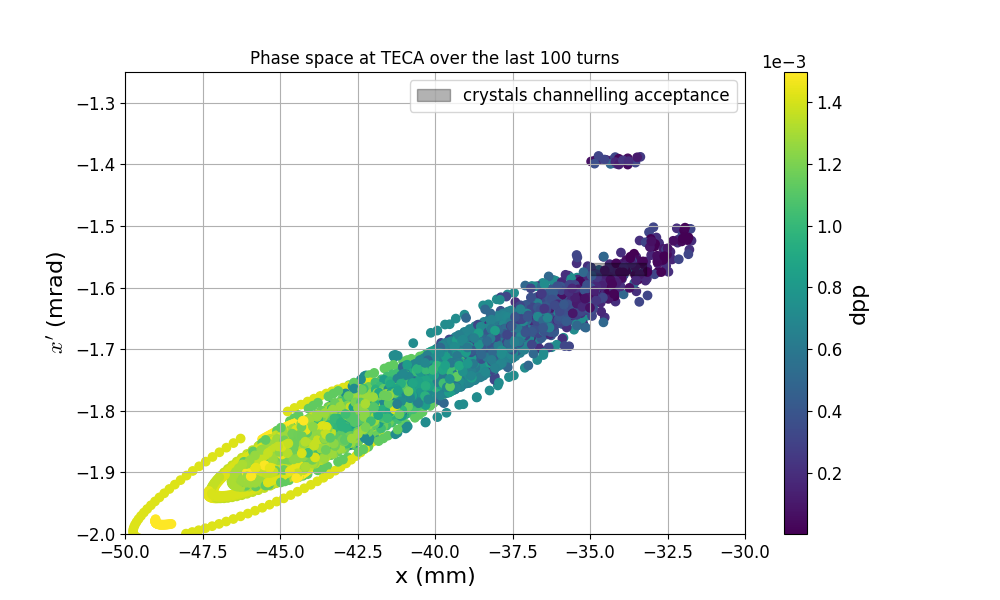

In [45]:
row_TECA_entry = tw_lss2_df.loc['TECA.entry']
row_TECA_exit = tw_lss2_df.loc['TECA.exit']


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for turn in range(num_turns):
    sc = ax.scatter(
        row_TECA_exit['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TECA_exit['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
plt.colorbar(sc, label='dpp')

ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')


#ax.plot([], [], 'k.', label='Particles at TECA entry')
#ax.plot([], [], 'b.', label='Particles after TECA')

ax.set_title("Phase space at TECA over the last 100 turns")
ax.legend()
ax.grid(True)

ax.set_xlim(-50, -30)
ax.set_ylim(-2, -1.25)

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

# Phase space at TPST for different dpp

Text(0, 0.5, "$x'$ (mrad)")

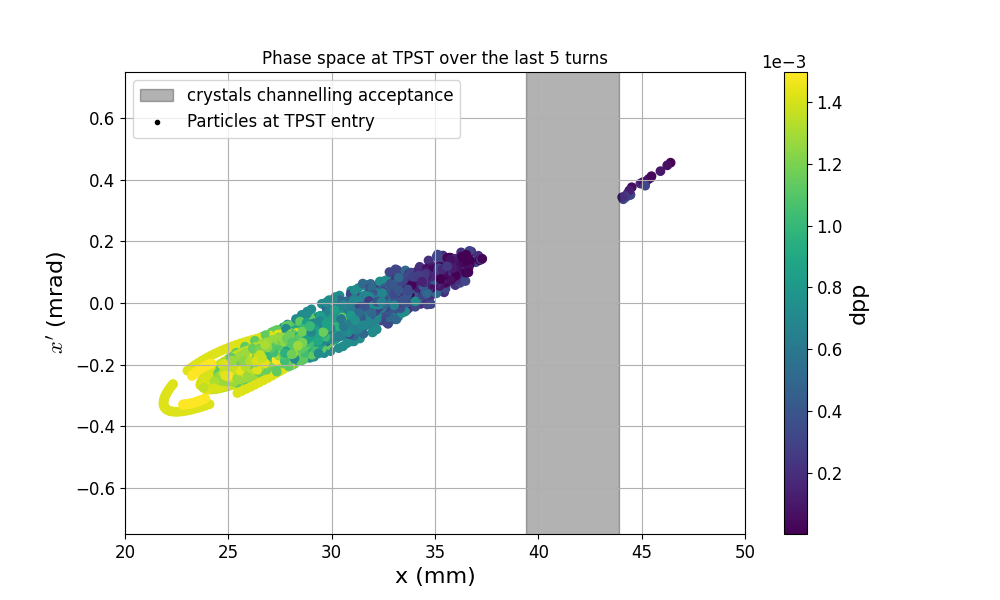

In [46]:
row_TPST_entry = tw_lss2_df.loc['tpst.21760_entry']


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

#ax.plot(row_TPST_entry['monitors'].x[:, :] * 1e3, row_TPST_entry['monitors'].px[:, :] * 1e3, 'k.', alpha=0.5)
for turn in range(num_turns):
    sc = ax.scatter(
        row_TPST_entry['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TPST_entry['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
plt.colorbar(sc, label='dpp')



#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
element_name = 'tpst.21760_entry.sep'
x = line[element_name].interaction_process.blade_position
thickness = line[element_name].interaction_process.thickness
ax.fill_between([x*1e3, x*1e3 + thickness*1e3],-1, 1, color='k', alpha=0.3, label='crystals channelling acceptance')



ax.plot([], [], 'k.', label='Particles at TPST entry')

ax.set_title("Phase space at TPST over the last 5 turns")

ax.legend()
ax.grid(True)

ax.set_xlim(20, 50)
ax.set_ylim(-0.75, 0.75)

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

### Phase space at TCSM location 

Text(0, 0.5, "$x'$ (mrad)")

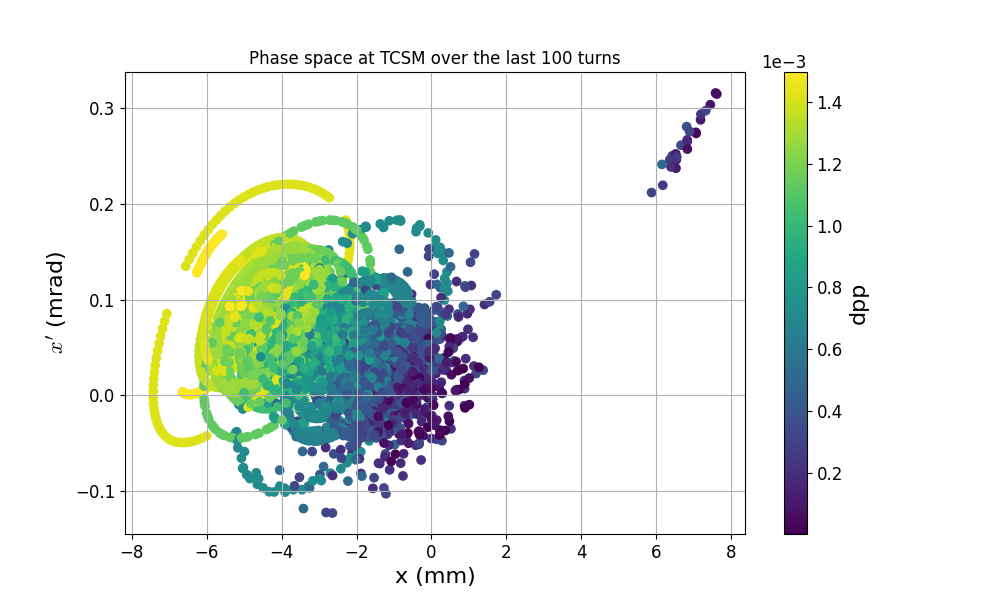

In [47]:
row_TCSM_entry = tw_lss2_df.loc['tcsm.51932.']


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for turn in range(num_turns):
    sc = ax.scatter(
        row_TCSM_entry['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TCSM_entry['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
plt.colorbar(sc, label='dpp')



ax.set_title("Phase space at TCSM over the last 100 turns")

ax.grid(True)

#ax.set_xlim(-6.5, 8)
#ax.set_ylim(-0.143, 0.307)

#ax.fill_between([5, 1000],-1, 1, color='k', alpha=0.3, label='TCSM collimator')



#ax.legend()
ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

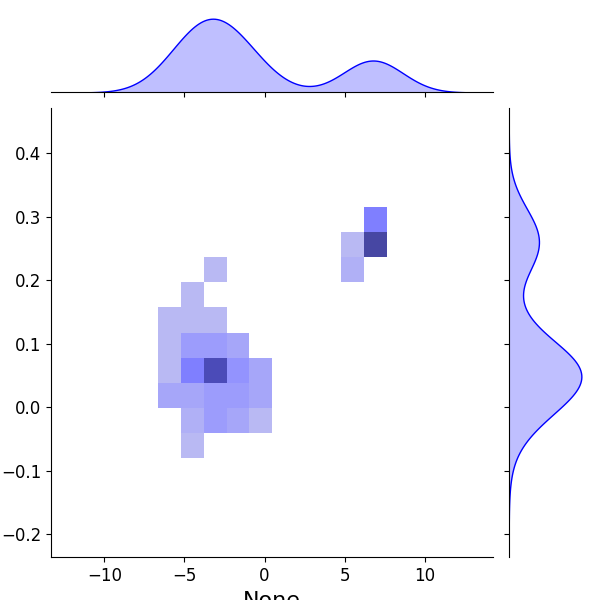

In [51]:
import seaborn as sns

row_TCSM_entry = tw_lss2_df.loc['tcsm.51932.']

x = row_TCSM_entry['monitors'].x[:, turn] * 1e3
px = row_TCSM_entry['monitors'].px[:, turn] * 1e3

image = sns.JointGrid(x=x, y=px)

image.plot_joint(sns.histplot, bins=10, color='blue')
image.plot_marginals(sns.kdeplot, color='blue', fill = True)


# Plotting the trajectories

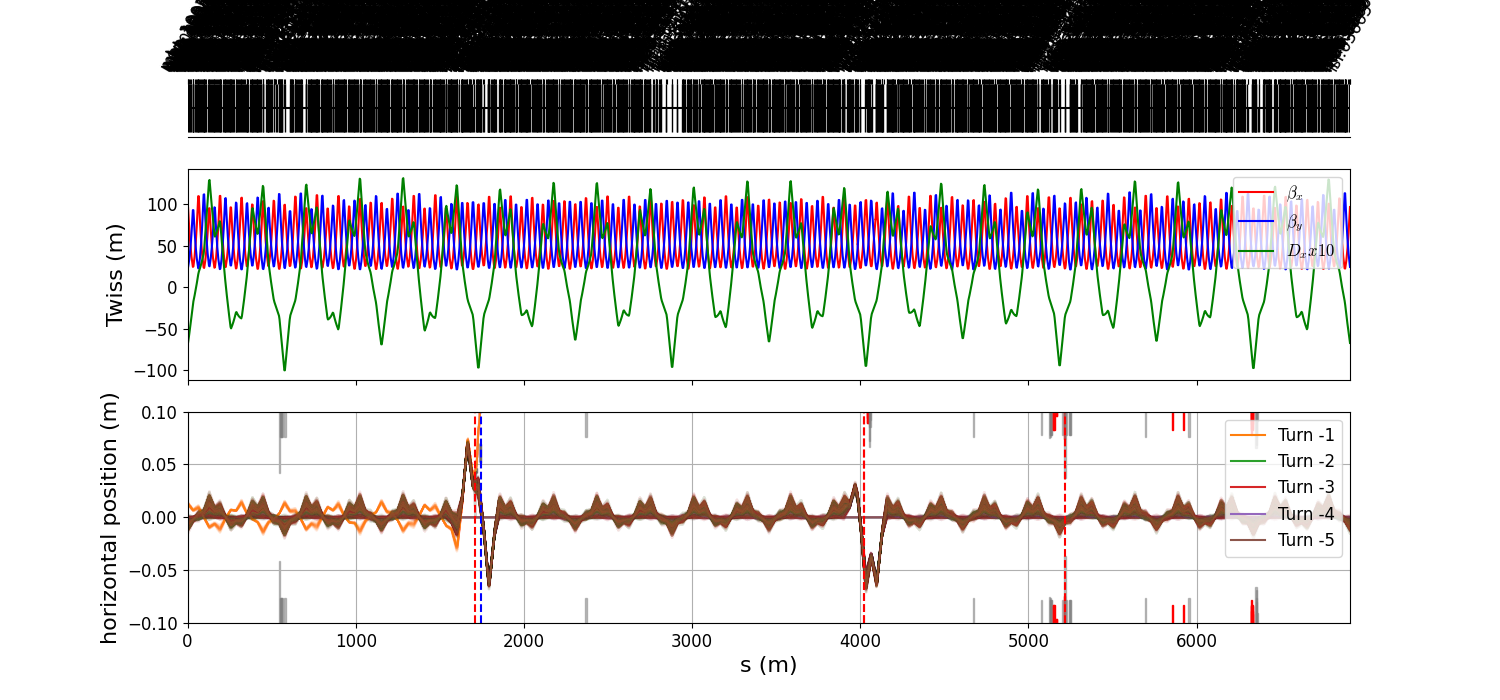

In [49]:
fig = plt.figure(figsize=(15,7))

plot_twiss(fig, tw_lss2, line)
fig.axes[2].grid(True)
fig.axes[2].set_xlabel('s (m)')
fig.axes[2].set_ylabel('horizontal position (m)')
fig.axes[2].set_ylim(-0.1, 0.1)

# plotting of the envelope
fig.axes[2].plot(tw_lss2.s, tw_lss2.x, 'r-')
#fig.axes[2].fill_between(tw_lss2.s, tw_lss2.x-sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), tw_lss2.x+sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), color='r', alpha=0.3, label='core envelope')



for element_name in septa_names_with_apertures:
    x = line[element_name].interaction_process.blade_position
    thickness = line[element_name].interaction_process.thickness
    s = line.get_table()['s', element_name]
    fig.axes[2].add_patch(mpl.patches.Rectangle((s, x), 1, thickness, color='k', alpha=0.3))
    
# Insert rectangles for each element in df_elements
for _, row in df_elements.iterrows():
    color = 'grey'
    alpha = 0.5
    if row['Element Name'] in [elem[0] for elem in blocking_elements]:
        color = 'red'
        alpha = 1.0
    # Rectangle from min_x to bottom
    rect_min = plt.Rectangle((row['Position'], -0.25), width=8, height=row['min_x'] + 0.25, color=color, alpha=alpha)
    fig.axes[2].add_patch(rect_min)
    
    # Rectangle from max_x to top
    rect_max = plt.Rectangle((row['Position'], row['max_x']), width=8, height=0.25 - row['max_x'], color=color, alpha=alpha)
    fig.axes[2].add_patch(rect_max)
   
## PLOTTING TRAJECTORIES   
n_traj = 500

ax = fig.axes[2]
alpha = 10/n_traj
plot_only_lost = False
num_turns = 5

all_trajs = tw_lss2_df.apply(lambda row: row['monitors'].x, axis=1)
all_trajs = np.stack(all_trajs.values)

for ipart in np.random.randint(0, particles._capacity, size=n_traj):
    state = particles.state[ipart]
    if plot_only_lost and state > 0:
        print(f"Skipping particle {ipart} ")
        continue

    particle_id = particles.particle_id[ipart]
    el_lost = particles.at_element[ipart]
    traj = all_trajs[:, particle_id, :]
    # print(f"Particle {ipart} lost at {el_lost} with state {state} and id {particle_id} ")

    if state <= 0:
        # need to recontruct the turns since the particle was last
        s_lost = line.get_table()['s', line.element_names[el_lost]]
        row_lost = tw_lss2_df[abs(tw_lss2_df['s'] - s_lost) < 30e-3].iloc[0]
        i_lost = row_lost['i_monitor']+1

        traj_corr = np.nan * np.ones_like(traj)
        traj_corr[:i_lost, -1] = traj[:i_lost, -1]
        for iturn in range(2, num_turns+1):
            traj_corr[:, -iturn] = np.hstack([traj[:i_lost, -iturn-1], traj[i_lost:, -iturn]])
        traj = traj_corr

    for iturn in range(1, num_turns+1):
        ax.plot(tw_lss2_df['s'], traj[:, -iturn], color=plt.cm.tab10(iturn), alpha=alpha, ls='-') 
for iturn in range(1, num_turns+1):
    ax.plot([], [], color=plt.cm.tab10(iturn), label=f"Turn -{iturn}")
ax.legend(loc="upper right")

fig.axes[2].axvline(x=tpst_position, color='r', linestyle='--', label='TPST location')
fig.axes[2].axvline(x=line.get_table()['s', 'tt20.extraction'], color='b', linestyle='--', label='TT20')
fig.axes[2].axvline(x=teca_position, color='r', linestyle='--', label='TECA location')
fig.axes[2].axvline(x=teca_position, color='r', linestyle='--', label='TECA location')
fig.axes[2].axvline(x=tcsm_position, color='r', linestyle='--', label='TCSM location')

